In [62]:
import numpy as np
import pandas as pd

### - GroupBy object : In Pandas, a GroupBy object represents the intermediate result of splitting a DataFrame (or Series) into groups based on some criteria — usually column values — before performing an aggregation, transformation, or filtration operation.

### - When you use the method .groupby() in pandas, it does not immediately perform any operation.
### Instead, it creates a GroupBy object, which is a special kind of iterator that holds:

1-Information about how the data is split into groups.

2-References to the original data.

3-Instructions for how to later aggregate or transform it.

# Why GroupBy() object not used on numerical data column ?
### - You can technically use groupby() on a numerical column, it usually doesn't yield a useful GroupBy object for typical data analysis tasks.

## Here's why this doesn't typically apply to numerical columns in the same way:
- **Many Unique Values** : Numerical columns often have a large number of unique values, making it impractical and not very meaningful to create a separate group for each individual numerical value. For example, if you tried to group by 'IMDB_Rating', you'd get a group for every single rating value, even if they differ by only a small decimal.

- **Purpose of Grouping** : The core idea of groupby() is to perform aggregations or transformations on meaningful categories. With numerical data, you usually want to perform calculations across the entire column or within groups defined by other categorical columns, rather than grouping by the numerical values themselves.

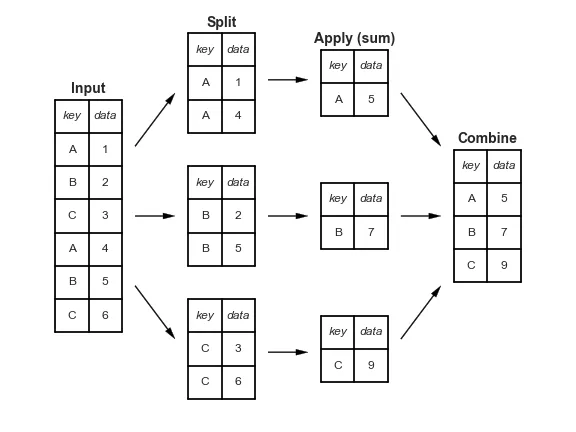

In [63]:
# importing 'imdb-top-1000.csv' DataFrame
movies = pd.read_csv('/content/drive/MyDrive/CSV_files/imdb-top-1000.csv')
movies

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76.0
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34075,195217415.0,84.0
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43374,30500000.0,85.0
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78.0


In [64]:
# creating groups using 'groupby()' object
genres = movies.groupby('Genre')     # grouping on basis of 'Genre' column
genres                               # 'genres' is a 'GroupBy' object now

# Note : Till now only 'groupby()' object is initialized on 'movies' DataFrame which contains info about grouping

In [65]:
# Applying aggregate functions on groupby objects
genres.min()

# Note : mean() , std() , var() , corr() can't be applied on categorical data

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,300,1924,45,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,33.0
Adventure,2001: A Space Odyssey,1925,88,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,41.0
Animation,Akira,1940,71,7.6,Adam Elliot,Adrian Molina,25229,128985.0,61.0
Biography,12 Years a Slave,1928,93,7.6,Adam McKay,Adrien Brody,27254,21877.0,48.0
Comedy,(500) Days of Summer,1921,68,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,45.0
Crime,12 Angry Men,1931,80,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,47.0
Drama,1917,1925,64,7.6,Aamir Khan,Abhay Deol,25088,3600.0,28.0
Family,E.T. the Extra-Terrestrial,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


### Some Questions

In [66]:
# find the top 3 genres by total earning
genres['Gross'].sum().sort_values(ascending = False).head(3)

# Note : genres['Gross'] is providing a 'Gross-series' of all 'genres' from all groupBy DataFrame means extracting 'Gross' column in every DataFrame group  first then apply sum()

,Gross
Genre,
Drama,3.540997e+10
Action,3.263226e+10
Comedy,1.566387e+10


In [67]:
# find the genre with highest avg IMDB rating
genres['IMDB_Rating'].mean().sort_values(ascending = False).head(1)

,IMDB_Rating
Genre,
Western,8.35


In [68]:
# find director with most popularity
directors = movies.groupby('Director')                                    # 'groupby' action on 'Director' column coz 'Director' can be same for many movies
directors['No_of_Votes'].sum().sort_values(ascending = False).head(1)     # fetching 'No_of_Votes' column then aggregating votes

,No_of_Votes
Director,
Christopher Nolan,11578345


In [69]:
# find the highest rated movie of each genre
movies.groupby('Genre')[['Series_Title' , 'IMDB_Rating']].max()

# Note : max() function is running on 'IMDB_Rating' column coz it is 'numerical' data column

,Series_Title,IMDB_Rating
Genre,,
Action,Yôjinbô,9.0
Adventure,Zombieland,8.6
Animation,Ôkami kodomo no Ame to Yuki,8.6
Biography,Zerkalo,8.9
Comedy,Zindagi Na Milegi Dobara,8.6
Crime,À bout de souffle,9.2
Drama,Zwartboek,9.3
Family,Willy Wonka & the Chocolate Factory,7.8
Fantasy,Nosferatu,8.1


In [70]:
# find the number of movies done by each actor
movies.groupby('Star1')['Series_Title'].count().sort_values(ascending = False)

,Series_Title
Star1,
Tom Hanks,12
Robert De Niro,11
Clint Eastwood,10
Al Pacino,10
Leonardo DiCaprio,9
...,...
Gérard Jugnot,1
Günes Sensoy,1
Haluk Bilginer,1


## GroupBy - Attributes and Methods

In [71]:
# find total number of groups after 'groupby()' -> len() function
# method-1
genres = movies.groupby('Genre')   # 'groupby' object stored as 'genres'
print(len(genres))

# method-2
movies['Genre'].nunique()

14


14

In [72]:
# find the number of rows in each group -> size() function

genres.size()   # sorted on basis of index label


,0
Genre,
Action,172
Adventure,72
Animation,82
Biography,88
Comedy,155
Crime,107
Drama,289
Family,2
Fantasy,2


In [73]:
# first and last item of each group
genres.first()    # first movie of each genre group
genres.last()     # last movie of each genre group
genres.nth(6)     # 7th movie of each genre group -> indexing starts from 0-6 hence '7th' movie is '6' index

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
27,Se7en,1995,127,Crime,8.6,David Fincher,Morgan Freeman,1445096,100125643.0,65.0
32,It's a Wonderful Life,1946,130,Drama,8.6,Frank Capra,James Stewart,405801,82385199.0,89.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
83,The Great Dictator,1940,125,Comedy,8.4,Charles Chaplin,Charles Chaplin,203150,288475.0,NaN
102,Braveheart,1995,178,Biography,8.3,Mel Gibson,Mel Gibson,959181,75600000.0,68.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
420,Sleuth,1972,138,Mystery,8.0,Joseph L. Mankiewicz,Laurence Olivier,44748,4081254.0,NaN
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0


In [74]:
# get_group() vs Filtering

# getgroup() : to see particualr group info by selecting the 'group' itself
genres.get_group('Horror')
genres.get_group('Fantasy')

# filtering
movies[movies['Genre'] == 'Horror']   # it uses comparing approach

''' get_group() is way more faster than filtering normally coz in filtering
we need to make groups and then filter but in get_group(), listed groups are already there
and need to fetch the particular group.'''

' get_group() is way more faster than filtering normally coz in filtering\nwe need to make groups and then filter but in get_group(), listed groups are already there\nand need to fetch the particular group.'

In [75]:
# 'groups' attribute : gives the dictionary of key-values(in list)
genres.groups    # each genre group becomes 'key' and indexes become 'values' in a list -> dictionary output

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [76]:
# describe() - mathematical summary of each numerical column from each group
genres.describe()     # sare 'groups' ke jitne numerical columns hai unki mathematical summary

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [77]:
# sample() : 1 random movie from each group
genres.sample()


# if any group doesn't have specified number of movies
genres.sample(2 , replace = True)    # 'replace = True' will show same movie result jis group mein sirf 1 hi movie hai

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
963,Die Hard: With a Vengeance,1995,128,Action,7.6,John McTiernan,Bruce Willis,364420,100012499.0,58.0
983,The Warriors,1979,92,Action,7.6,Walter Hill,Michael Beck,93878,22490039.0,65.0
306,Le salaire de la peur,1953,131,Adventure,8.1,Henri-Georges Clouzot,Yves Montand,54588,124570860.0,85.0
137,Queen,2013,146,Adventure,8.2,Vikas Bahl,Kangana Ranaut,60701,1429534.0,NaN
386,Pâfekuto burû,1997,81,Animation,8.0,Satoshi Kon,Junko Iwao,58192,776665.0,NaN
378,The Incredibles,2004,115,Animation,8.0,Brad Bird,Craig T. Nelson,657047,261441092.0,90.0
650,October Sky,1999,108,Biography,7.8,Joe Johnston,Jake Gyllenhaal,82855,32481825.0,71.0
35,The Intouchables,2011,112,Biography,8.5,Olivier Nakache,Éric Toledano,760360,13182281.0,57.0
717,Duck Soup,1933,69,Comedy,7.8,Leo McCarey,Groucho Marx,55581,350197185.0,93.0
973,Home Alone,1990,103,Comedy,7.6,Chris Columbus,Macaulay Culkin,488817,285761243.0,63.0


In [78]:
# nunique() : unique values in each group for each column
genres.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0


## agg() method : to apply multiple aggregation functions on multiple columns

In [79]:
# passing dictionary{}
genres.agg({
    'Runtime' : 'mean',
    'IMDB_Rating' : 'mean',
    'No_of_Votes' : 'sum',
    'Gross' : 'sum',
    'Metascore' : 'min'
})

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [80]:
# passing list[]

# Apply aggregation functions only to numerical columns
numerical_cols = ['Runtime', 'IMDB_Rating', 'No_of_Votes', 'Gross', 'Metascore']    # collecting 'numerical' columns only otherwise 'Categorical' columns pe 'numerical' operations nhi chalenge
genres_agg = genres[numerical_cols].agg(['min', 'max', 'mean'])    # agg([columns]) -> list is added

display(genres_agg)

Runtime                  IMDB_Rating                No_of_Votes  \
              min  max        mean         min  max      mean         min   
Genre                                                                       
Action         45  321  129.046512         7.6  9.0  7.949419       25312   
Adventure      88  228  134.111111         7.6  8.6  7.937500       29999   
Animation      71  137   99.585366         7.6  8.6  7.930488       25229   
Biography      93  209  136.022727         7.6  8.9  7.938636       27254   
Comedy         68  188  112.129032         7.6  8.6  7.901290       26337   
Crime          80  229  126.392523         7.6  9.2  8.016822       27712   
Drama          64  242  124.737024         7.6  9.3  7.957439       25088   
Family        100  115  107.500000         7.8  7.8  7.800000      178731   
Fantasy        76   94   85.000000         7.9  8.1  8.000000       57428   
Film-Noir     100  108  104.000000         7.8  8.1  7.966667       59556   
Horror         71  122  102.090909         7.6  8.5  7.909091       27007   
Mystery        96  138  119.083333         7.6  8.4  7.975000       33982   
Thriller      108  108  108.000000         7.8  7.8  7.800000       27733   
Western       132  165  148.250000         7.8  8.8  8.350000       65659   

                                         Gross                             \
               max           mean          min          max          mean   
Genre                                                                       
Action     2303232  420246.581395       3296.0  936662225.0  1.897224e+08   
Adventure  1512360  313557.819444      61001.0  874211619.0  1.319017e+08   
Animation   999790  268032.073171     128985.0  873839108.0  1.784326e+08   
Biography  1213505  272805.045455      21877.0  753585104.0  9.404952e+07   
Comedy      939631  178195.658065       1305.0  886752933.0  1.010572e+08   
Crime      1826188  313398.271028       6013.0  790482117.0  7.899656e+07   
Drama      2343110  212343.612457       3600.0  924558264.0  1.225259e+08   
Family      372490  275610.500000    4000000.0  435110554.0  2.195553e+08   
Fantasy      88794   73111.000000  337574718.0  445151978.0  3.913633e+08   
Film-Noir   158731  122405.000000     449191.0  123353292.0  4.197018e+07   
Horror      787806  340232.363636      89029.0  298791505.0  9.405902e+07   
Mystery    1129894  350250.333333    1035953.0  474203697.0  1.047014e+08   
Thriller     27733   27733.000000   17550741.0   17550741.0  1.755074e+07   
Western     688390  322416.250000    5321508.0   31800000.0  1.455538e+07   

          Metascore                    
                min    max       mean  
Genre                                  
Action         33.0   98.0  73.419580  
Adventure      41.0  100.0  78.437500  
Animation      61.0   96.0  81.093333  
Biography      48.0   97.0  76.240506  
Comedy         45.0   99.0  78.720000  
Crime          47.0  100.0  77.080460  
Drama          28.0  100.0  79.701245  
Family         67.0   91.0  79.000000  
Fantasy         NaN    NaN        NaN  
Film-Noir      94.0   97.0  95.666667  
Horror         46.0   97.0  80.000000  
Mystery        52.0  100.0  79.125000  
Thriller       81.0   81.0  81.000000  
Western        69.0   90.0  78.250000

In [81]:
# passing dict and list
genres.agg({
    'Runtime' : ['min' , 'mean'],
    'IMDB_Rating' : ['min' , 'max'],
    'No_of_Votes' : 'sum',
    'Gross' : 'sum',
    'Metascore' : ['mean' , 'min' , 'max']
})

Runtime             IMDB_Rating      No_of_Votes         Gross  \
              min        mean         min  max         sum           sum   
Genre                                                                      
Action         45  129.046512         7.6  9.0    72282412  3.263226e+10   
Adventure      88  134.111111         7.6  8.6    22576163  9.496922e+09   
Animation      71   99.585366         7.6  8.6    21978630  1.463147e+10   
Biography      93  136.022727         7.6  8.9    24006844  8.276358e+09   
Comedy         68  112.129032         7.6  8.6    27620327  1.566387e+10   
Crime          80  126.392523         7.6  9.2    33533615  8.452632e+09   
Drama          64  124.737024         7.6  9.3    61367304  3.540997e+10   
Family        100  107.500000         7.8  7.8      551221  4.391106e+08   
Fantasy        76   85.000000         7.9  8.1      146222  7.827267e+08   
Film-Noir     100  104.000000         7.8  8.1      367215  1.259105e+08   
Horror         71  102.090909         7.6  8.5     3742556  1.034649e+09   
Mystery        96  119.083333         7.6  8.4     4203004  1.256417e+09   
Thriller      108  108.000000         7.8  7.8       27733  1.755074e+07   
Western       132  148.250000         7.8  8.8     1289665  5.822151e+07   

           Metascore               
                mean   min    max  
Genre                              
Action     73.419580  33.0   98.0  
Adventure  78.437500  41.0  100.0  
Animation  81.093333  61.0   96.0  
Biography  76.240506  48.0   97.0  
Comedy     78.720000  45.0   99.0  
Crime      77.080460  47.0  100.0  
Drama      79.701245  28.0  100.0  
Family     79.000000  67.0   91.0  
Fantasy          NaN   NaN    NaN  
Film-Noir  95.666667  94.0   97.0  
Horror     80.000000  46.0   97.0  
Mystery    79.125000  52.0  100.0  
Thriller   81.000000  81.0   81.0  
Western    78.250000  69.0   90.0

## Looping on groups : provides 'group_name' and 'group_data' for each and every group

In [82]:
# fetch 'group_name' and first row of every from every group-data
for group_name, group_data in genres:
  print(f"Group: {group_name}")
  display(group_data.head(1))          # Display the first row of each group

Group: Action


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0


Group: Adventure


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
21,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0


Group: Animation


...

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
69,Memento,2000,113,Mystery,8.4,Christopher Nolan,Guy Pearce,1125712,25544867.0,80.0


Group: Thriller


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
700,Wait Until Dark,1967,108,Thriller,7.8,Terence Young,Audrey Hepburn,27733,17550741.0,81.0


Group: Western


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
12,"Il buono, il brutto, il cattivo",1966,161,Western,8.8,Sergio Leone,Clint Eastwood,688390,6100000.0,90.0


In [83]:
# fetch max and min imdb_rating for every group to locate in an empty DataFrame
df = pd.DataFrame(columns = movies.columns)   # empty DataFrame
result_dfs = []                               # Use a list to collect DataFrames

for group_name, group_data in genres:
  # Append the group name (as a DataFrame)
  group_name_df = pd.DataFrame([{'Genre': group_name}])
  result_dfs.append(group_name_df)

  # Append the row with the max IMDB rating
  max_rating_row = group_data[group_data['IMDB_Rating'] == group_data['IMDB_Rating'].max()]
  result_dfs.append(max_rating_row)

  # Append the row with the min IMDB rating
  min_rating_row = group_data[group_data['IMDB_Rating'] == group_data['IMDB_Rating'].min()]
  result_dfs.append(min_rating_row)

# Concatenate all DataFrames in the list
df = pd.concat(result_dfs, ignore_index=True)

display(df)

''' Note : By setting ignore_index=True, you instruct pandas to discard the original
indices from the DataFrames being concatenated and assign a new, continuous integer index starting
from 0 to the final combined DataFrame '''

,Genre,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,Action,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Action,The Dark Knight,2008,152.0,9.0,Christopher Nolan,Christian Bale,2303232.0,534858444.0,84.0
2,Action,Guardians of the Galaxy Vol. 2,2017,136.0,7.6,James Gunn,Chris Pratt,569974.0,389813101.0,67.0
3,Action,Baby Driver,2017,113.0,7.6,Edgar Wright,Ansel Elgort,439406.0,107825862.0,86.0
4,Action,Only the Brave,2017,134.0,7.6,Joseph Kosinski,Josh Brolin,58371.0,18340051.0,72.0
...,...,...,...,...,...,...,...,...,...,...
155,Thriller,Wait Until Dark,1967,108.0,7.8,Terence Young,Audrey Hepburn,27733.0,17550741.0,81.0
156,Thriller,Wait Until Dark,1967,108.0,7.8,Terence Young,Audrey Hepburn,27733.0,17550741.0,81.0
157,Western,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,Western,"Il buono, il brutto, il cattivo",1966,161.0,8.8,Sergio Leone,Clint Eastwood,688390.0,6100000.0,90.0


' Note : By setting ignore_index=True, you instruct pandas to discard the original\nindices from the DataFrames being concatenated and assign a new, continuous integer index starting\nfrom 0 to the final combined DataFrame '

## split -> apply -> combine strategy

### apply() function use cases

In [84]:
# find number of movies starting with 'A' for each group

genres['Series_Title'].apply(lambda x : x.str.startswith('A').sum())    # 'x' is a data 'series' here which contains names of all the movies

,Series_Title
Genre,
Action,10
Adventure,2
Animation,2
Biography,9
Comedy,14
Crime,4
Drama,21
Family,0
Fantasy,0


In [85]:
# find ranking of each movie in the group according to IMDB ratings
def Ranking(group):
  group['Rankings'] = group['IMDB_Rating'].rank(ascending = False)      # adding 'Ranking' column in every group as per their ranks
  return group

genres.apply(Ranking , include_groups = False)    # include_groups = False

''' Note : Ranking function returns the entire group DataFrame with a new 'Rankings' column, setting 'include_groups=False' means
the resulting DataFrame's index is the original index of the movies DataFrame, and 'Genre' remains a regular
 column. If you had kept 'include_groups=True', the index would have been a MultiIndex with 'Genre' as the first level and the original
 index as the second level.'''

" Note : Ranking function returns the entire group DataFrame with a new 'Rankings' column, setting 'include_groups=False' means\nthe resulting DataFrame's index is the original index of the movies DataFrame, and 'Genre' remains a regular\n column. If you had kept 'include_groups=True', the index would have been a MultiIndex with 'Genre' as the first level and the original\n index as the second level."

In [86]:
# find normalized IMDB rating group-wise
# Normalized formula = (X - Xmin) / (Xmax -Xmin)
# Normalized_value = 1 -> max value in the group
# Normalized_value = 0 -> min value in the group

def normal(group):
  group['Norm_ranking'] = (group['IMDB_Rating'] - group['IMDB_Rating'].min()) / (group['IMDB_Rating'].max() - group['IMDB_Rating'].min())
  return group

genres.apply(normal , include_groups = False)

Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime  IMDB_Rating           Director              Star1  \
Genre                                                                      
Action   2        152          9.0  Christopher Nolan     Christian Bale   
         5        201          8.9      Peter Jackson        Elijah Wood   
         8        148          8.8  Christopher Nolan  Leonardo DiCaprio   
         10       178          8.8      Peter Jackson        Elijah Wood   
         13       179          8.7      Peter Jackson        Elijah Wood   
...               ...          ...                ...                ...   
Thriller 700      108          7.8      Terence Young     Audrey Hepburn   
Western  12       161          8.8       Sergio Leone     Clint Eastwood   
         48       165          8.5       Sergio Leone        Henry Fonda   
         115      132          8.3       Sergio Leone     Clint Eastwood   
         691      135          7.8     Clint Eastwood     Clint Eastwood   

              No_of_Votes        Gross  Metascore  Norm_ranking  
Genre                                                            
Action   2        2303232  534858444.0       84.0      1.000000  
         5        1642758  377845905.0       94.0      0.928571  
         8        2067042  292576195.0       74.0      0.857143  
         10       1661481  315544750.0       92.0      0.857143  
         13       1485555  342551365.0       87.0      0.785714  
...                   ...          ...        ...           ...  
Thriller 700        27733   17550741.0       81.0           NaN  
Western  12        688390    6100000.0       90.0      1.000000  
         48        302844    5321508.0       80.0      0.700000  
         115       232772   15000000.0       74.0      0.500000  
         691        65659   31800000.0       69.0      0.000000  

[1000 rows x 10 columns]

## 'groupby()' on multiple columns

In [87]:
duo = movies.groupby(['Director' , 'Star1'])   # now unique combinations of Director-Star1 made different groups
duo          # groupby object

# size() - provides the size of the each group made
duo.size()

# get_group() - provides the group-info for each and every group
duo.get_group(('Aamir Khan' , 'Amole Gupte'))     # ()-tuple needs to be provided to fetch out data from a particular group

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN


In [88]:
# find the most earning actor-director combo
duo['Gross'].sum().sort_values(ascending = False)



,,Gross
Director,Star1,
Akira Kurosawa,Toshirô Mifune,2.999877e+09
Anthony Russo,Joe Russo,2.205039e+09
Billy Wilder,William Holden,1.286779e+09
Christopher Nolan,Christian Bale,1.242940e+09
Werner Herzog,Klaus Kinski,1.124605e+09
...,...,...
Jeong-beom Lee,Won Bin,6.460000e+03
Shane Meadows,Paddy Considine,6.013000e+03
Jaco Van Dormael,Jared Leto,3.600000e+03


In [89]:
# find the best(in-terms of MetaScore(avg)) actor -> genre combo
combo = movies.groupby(['Star1' , 'Genre'])
combo['Metascore'].mean().reset_index().sort_values('Metascore' , ascending = False).head(1)


'''
1- combo['Metascore'].mean() -> calculating the mean of each unique group of 'Star' and 'Genre' combo
2- reset_index() -> reseting the index to original DataFrame i.e. 'integers'
3- sort_values('Metascore' , ascending = False) -> sorting on basis of 'Metascore' values
'''

"\n1- combo['Metascore'].mean() -> calculating the mean of each unique group of 'Star' and 'Genre' combo\n2- reset_index() -> reseting the index to original DataFrame i.e. 'integers'\n3- sort_values('Metascore' , ascending = False) -> sorting on basis of 'Metascore' values\n"

## agg() function on multiple columns

In [90]:
# passing dictionary{}
duo.agg({
    'Runtime': ['mean', 'min', 'max'],
    'IMDB_Rating': ['mean', 'min', 'max'],
    'No_of_Votes': ['mean', 'min', 'max'],
    'Gross': ['mean', 'min', 'max'],
    'Metascore': ['mean', 'min', 'max']
})

Runtime           IMDB_Rating            \
                                      mean  min  max        mean  min  max   
Director            Star1                                                    
Aamir Khan          Amole Gupte      165.0  165  165         8.4  8.4  8.4   
Aaron Sorkin        Eddie Redmayne   129.0  129  129         7.8  7.8  7.8   
Abdellatif Kechiche Léa Seydoux      180.0  180  180         7.7  7.7  7.7   
Abhishek Chaubey    Shahid Kapoor    148.0  148  148         7.8  7.8  7.8   
Abhishek Kapoor     Amit Sadh        130.0  130  130         7.7  7.7  7.7   
...                                    ...  ...  ...         ...  ...  ...   
Zaza Urushadze      Lembit Ulfsak     87.0   87   87         8.2  8.2  8.2   
Zoya Akhtar         Hrithik Roshan   155.0  155  155         8.1  8.1  8.1   
                    Vijay Varma      154.0  154  154         8.0  8.0  8.0   
Çagan Irmak         Çetin Tekindor   112.0  112  112         8.3  8.3  8.3   
Ömer Faruk Sorak    Cem Yilmaz       127.0  127  127         8.0  8.0  8.0   

                                   No_of_Votes                        Gross  \
                                          mean     min     max         mean   
Director            Star1                                                     
Aamir Khan          Amole Gupte       168895.0  168895  168895    1223869.0   
Aaron Sorkin        Eddie Redmayne     89896.0   89896   89896  853090410.0   
Abdellatif Kechiche Léa Seydoux       138741.0  138741  138741    2199675.0   
Abhishek Chaubey    Shahid Kapoor      27175.0   27175   27175  218428303.0   
Abhishek Kapoor     Amit Sadh          32628.0   32628   32628    1122527.0   
...                                        ...     ...     ...          ...   
Zaza Urushadze      Lembit Ulfsak      40382.0   40382   40382     144501.0   
Zoya Akhtar         Hrithik Roshan     67927.0   67927   67927    3108485.0   
                    Vijay Varma        31886.0   31886   31886    5566534.0   
Çagan Irmak         Çetin Tekindor     78925.0   78925   78925  461855363.0   
Ömer Faruk Sorak    Cem Yilmaz         56960.0   56960   56960  196206077.0   

                                                             Metascore        \
                                            min          max      mean   min   
Director            Star1                                                      
Aamir Khan          Amole Gupte       1223869.0    1223869.0       NaN   NaN   
Aaron Sorkin        Eddie Redmayne  853090410.0  853090410.0      77.0  77.0   
Abdellatif Kechiche Léa Seydoux       2199675.0    2199675.0      89.0  89.0   
Abhishek Chaubey    Shahid Kapoor   218428303.0  218428303.0       NaN   NaN   
Abhishek Kapoor     Amit Sadh         1122527.0    1122527.0      40.0  40.0   
...                                         ...          ...       ...   ...   
Zaza Urushadze      Lembit Ulfsak      144501.0     144501.0      73.0  73.0   
Zoya Akhtar         Hrithik Roshan    3108485.0    3108485.0       NaN   NaN   
                    Vijay Varma       5566534.0    5566534.0      65.0  65.0   
Çagan Irmak         Çetin Tekindor  461855363.0  461855363.0       NaN   NaN   
Ömer Faruk Sorak    Cem Yilmaz      196206077.0  196206077.0       NaN   NaN   

                                          
                                     max  
Director            Star1                 
Aamir Khan          Amole Gupte      NaN  
Aaron Sorkin        Eddie Redmayne  77.0  
Abdellatif Kechiche Léa Seydoux     89.0  
Abhishek Chaubey    Shahid Kapoor    NaN  
Abhishek Kapoor     Amit Sadh       40.0  
...                                  ...  
Zaza Urushadze      Lembit Ulfsak   73.0  
Zoya Akhtar         Hrithik Roshan   NaN  
                    Vijay Varma     65.0  
Çagan Irmak         Çetin Tekindor   NaN  
Ömer Faruk Sorak    Cem Yilmaz       NaN  

[898 rows x 15 columns]

## Exercise Questions on IPL DataSet

In [91]:
ipl = pd.read_csv('/content/drive/MyDrive/CSV_files/deliveries.csv')
ipl

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [92]:
# find the top 10 batsman in terms of runs
ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending = False).head(10)

,batsman_runs
batsman,
V Kohli,5434
SK Raina,5415
RG Sharma,4914
DA Warner,4741
S Dhawan,4632
CH Gayle,4560
MS Dhoni,4477
RV Uthappa,4446
AB de Villiers,4428


In [93]:
# find the batsman with max number of sixes
six = ipl[ipl['batsman_runs'] == 6]    # filterling : balls only where batsman hit 6 runs
six

six.groupby('batsman')['batsman_runs'].count().sort_values(ascending = False).head(1)   # groupby() and aggregation

,batsman_runs
batsman,
CH Gayle,327


In [95]:
# find batsman with most number of 4's and 6's in last 5 overs
temp_df = ipl[ipl['over'] > 15]   # filtering : last 5 overs only

temp_df = temp_df[(temp_df['batsman_runs'] == 4) | (temp_df['batsman_runs'] == 6)]             # only those balls on which '4' or '6' runs scored

temp_df.groupby('batsman')['batsman_runs'].count().sort_values(ascending = False).head(1)      # grouping on 'batsman' and fetching 'batsman_runs' column

,batsman_runs
batsman,
MS Dhoni,340


In [96]:
# find V Kohli's record against all teams
vk = ipl[ipl['batsman'] == 'V Kohli']     # filtering = 'batsman' is 'V kohli' only
vk

vk.groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending = False)    # grouping on basis of 'bowling_team' and then fetching 'batsman_runs' and then sum()

,batsman_runs
bowling_team,
Delhi Daredevils,763
Chennai Super Kings,749
Kolkata Knight Riders,675
Kings XI Punjab,636
Mumbai Indians,628
Sunrisers Hyderabad,509
Rajasthan Royals,370
Deccan Chargers,306
Gujarat Lions,283


In [98]:
# create a function that can return the highest score  of any 'batsman'
def highest(batsman):
  temp_df = ipl[ipl['batsman'] == batsman]   # filtering : rows in which given 'batsman' was there only
  return temp_df.groupby('match_id')['total_runs'].sum().sort_values(ascending = False).head(1)

highest('MS Dhoni')

# Explanation
''' temp_df.groupby('match_id')['batsman_runs'].sum()
1- groupby('match_id') -> grouping on basis of match id coz in temp_df we got only those rows which have our batsman
2- ['batsman_runs'] -> fetching batsman_runs column from DataFrame
3- sum() -> summing all the runs scored by batsman on every ball
4- sort_values(ascending = False) -> sorting the final DataFrame on basis of highest runs scored by given 'batsman' in particular 'match_id'
'''

,total_runs
match_id,
11330,94
